In [1]:
import pickle
import torch
import os
import csv

import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from torchvision import transforms
from PIL import Image
from torch.utils.data import Dataset
from huggingface_hub import login
from transformers import AutoImageProcessor, ViTForImageClassification, TrainingArguments, Trainer, EarlyStoppingCallback
from dotenv import load_dotenv

In [ ]:
### Login for Hugging Face model
load_dotenv()
login(token=os.environ["HF_TOKEN"])

### Setam seedul pt random
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
torch.cuda.manual_seed_all(SEED)

### Variabile globale

MODEL_NAME = "google/vit-large-patch16-224"
SPOSE_PATH = "spose_embedding_49d_sorted.txt"
IMAGE_SIZE = 224
EVAL_RESIZE = 256 

### VIT processor + move device to cuda
image_processor = AutoImageProcessor.from_pretrained(MODEL_NAME, use_fast = True)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

### Augmentare inspirata din cum augumenteaza lucrarea datele pentru CUB
train_transform = transforms.Compose([
    transforms.RandomResizedCrop(IMAGE_SIZE, scale=(0.8, 1.0), interpolation=transforms.InterpolationMode.BICUBIC),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2),
])

eval_transform = transforms.Compose([
    transforms.Resize(EVAL_RESIZE, interpolation=transforms.InterpolationMode.BICUBIC),
    transforms.CenterCrop(IMAGE_SIZE),
])

### Dataset pentru x -> c
class ConceptDataset(Dataset):
    def __init__(self, images_paths, labels_49d, aug=None):
        self.images_paths = images_paths
        self.labels = labels_49d
        self.aug = aug

    def __len__(self):
        return len(self.images_paths)

    def __getitem__(self, idx):
        img = Image.open(self.images_paths[idx]).convert("RGB")
        
        if self.aug is not None:
            img = self.aug(img)
            
        inputs = image_processor(
            images=img, 
            return_tensors="pt",
            do_resize=False,
            do_center_crop=False
        )
        
        pixel_values = inputs["pixel_values"].squeeze(0)
        label_tensor = torch.tensor(self.labels[idx], dtype=torch.float32)
        
        return {"pixel_values": pixel_values, "labels": label_tensor}

### Metricile pe care le va urmarii modelul
# Metrici x->c

def compute_metrics(eval_pred):
    predictions, labels = eval_pred
    
    mse = mean_squared_error(labels, predictions)
    r2 = r2_score(labels, predictions)
    
    return {"mse": mse, "r2_score": r2}


Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.


In [ ]:
### Load images + labels parsing
with open("all_images.pkl", "rb") as f:
    imgs_path = pickle.load(f)
    
spose_matrix = np.loadtxt(SPOSE_PATH)

label_names = {name: i for i, name in enumerate(list(imgs_path.keys()))}
all_data = []
all_labels = []


for s in imgs_path:
    np.random.shuffle(imgs_path[s])
    
    all_data.extend(imgs_path[s])
    position = label_names[s]
    all_labels.extend([spose_matrix[position]] * len(imgs_path[s]))
    
    
print(len(all_data), len(all_labels))

# 80% din date pentru tain si 20% pt test
aux_data, test_data, aux_labels, test_labels = train_test_split(
    all_data, all_labels, 
    test_size=0.20, 
    random_state=SEED, 
    stratify=all_labels
)

# Alegem 20% din datele de train pentru evaluare
train_data, eval_data, train_labels, eval_labels = train_test_split(
    aux_data, aux_labels, 
    test_size=0.20, 
    random_state=SEED,
    stratify=aux_labels
)

train_dataset = ConceptDataset(train_data, train_labels, train_transform)
val_dataset = ConceptDataset(eval_data, eval_labels, eval_transform)
test_dataset = ConceptDataset(test_data, test_labels, eval_transform)

26107 26107


In [ ]:

### Modelul x -> c
model = ViTForImageClassification.from_pretrained(
    "./vit/run1/models",
    num_labels=49,
    ignore_mismatched_sizes=True
)
model.config.problem_type = "regression"
model = model.to(device)

run_idx = 1
while os.path.exists(f"./vit_feature_prediction/run{run_idx}"):
    run_idx += 1
run_dir        = f"./vit_feature_prediction/run{run_idx}"
checkpoint_dir = os.path.join(run_dir, "checkpoints")
model_dir      = os.path.join(run_dir, "models")

os.makedirs(checkpoint_dir, exist_ok=True)
os.makedirs(model_dir,      exist_ok=True)

args = TrainingArguments(
    output_dir=checkpoint_dir,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    # gradient_accumulation_steps=2,
    report_to="none",
    num_train_epochs=50,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model ="mse",
    greater_is_better = False,
    learning_rate=2e-5,
    warmup_ratio=0.1,
    weight_decay=0.01,
    remove_unused_columns=False,
)

trainer = Trainer(
    model=model,
    args=args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=5)],
)


Loading weights:   0%|          | 0/392 [00:00<?, ?it/s]

ViTForImageClassification LOAD REPORT from: ./vit/run1/models
Key               | Status   |                                                                                             
------------------+----------+---------------------------------------------------------------------------------------------
classifier.bias   | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([1854]) vs model:torch.Size([49])            
classifier.weight | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([1854, 1024]) vs model:torch.Size([49, 1024])

Notes:
- MISMATCH	:ckpt weights were loaded, but they did not match the original empty weight shapes.
warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


In [ ]:
train_output = trainer.train()
trainer.save_model(model_dir)

Epoch,Training Loss,Validation Loss,Mse,R2 Score
1,0.071439,0.057386,0.057386,0.189530
2,0.046425,0.042327,0.042327,0.391997
3,0.037204,0.034871,0.034871,0.499534
4,0.028701,0.027626,0.027626,0.596349
5,0.019958,0.023490,0.023490,0.666068
6,0.012936,0.018699,0.018699,0.727007
7,0.008477,0.016554,0.016554,0.760158
8,0.006071,0.014922,0.014922,0.784101
9,0.004601,0.013757,0.013757,0.801633
10,0.003503,0.012935,0.012935,0.814679


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

In [7]:
trainer.callback_handler.callbacks = [
    cb for cb in trainer.callback_handler.callbacks 
    if cb.__class__.__name__ in ["ProgressCallback", "DefaultFlowCallback", "PrinterCallback"]
]

test_results = trainer.evaluate(test_dataset)

print("\nTest Results:")
print(f"MSE: {test_results['eval_mse']:.4f}")
print(f"R2: {test_results['eval_r2_score']:.4f}")
print(f"Loss: {test_results['eval_loss']:.4f}")

test_results_path = os.path.join(run_dir, "test_results.txt")
with open(test_results_path, "w") as f:
    f.write(f"Test Results:\n")
    f.write(f"MSE: {test_results['eval_mse']:.4f}\n")
    f.write(f"R2: {test_results['eval_r2_score']:.4f}\n")
    f.write(f"Loss: {test_results['eval_loss']:.4f}\n")

print(f"\nTest results saved to: {test_results_path}")


Test Results:
MSE: 0.0080
R2: 0.8883
Loss: 0.0080

Test results saved to: ./vit_feature_prediction/run1\test_results.txt


In [8]:
print(trainer.state.log_history)
eval_history = [entry for entry in trainer.state.log_history]
print(eval_history)

[{'loss': 0.263701171875, 'grad_norm': 0.5114158987998962, 'learning_rate': 1.910047846889952e-06, 'epoch': 0.4784688995215311, 'step': 500}, {'loss': 0.0714388885498047, 'grad_norm': 0.48899486660957336, 'learning_rate': 3.823923444976077e-06, 'epoch': 0.9569377990430622, 'step': 1000}, {'eval_loss': 0.057386476546525955, 'eval_mse': 0.05738646537065506, 'eval_r2_score': 0.1895296722650528, 'eval_runtime': 151.1411, 'eval_samples_per_second': 27.636, 'eval_steps_per_second': 1.733, 'epoch': 1.0, 'step': 1045}, {'loss': 0.05311124801635742, 'grad_norm': 0.4223884046077728, 'learning_rate': 5.737799043062201e-06, 'epoch': 1.4354066985645932, 'step': 1500}, {'loss': 0.04642537307739258, 'grad_norm': 0.35063669085502625, 'learning_rate': 7.651674641148325e-06, 'epoch': 1.9138755980861244, 'step': 2000}, {'eval_loss': 0.042327214032411575, 'eval_mse': 0.04232720285654068, 'eval_r2_score': 0.39199650287628174, 'eval_runtime': 153.0733, 'eval_samples_per_second': 27.288, 'eval_steps_per_seco

In [13]:
eval_history = [entry for entry in trainer.state.log_history if "eval_loss" in entry]

csv_path = os.path.join(checkpoint_dir, "result.csv")
with open(csv_path, "w", newline="") as f:
    writer = csv.DictWriter(f, fieldnames=["epoch", "loss", "mse", "acc"])
    writer.writeheader()
    for entry in eval_history:
        writer.writerow({
            "epoch": entry["epoch"],
            "loss":  entry["eval_loss"],
            "mse":   entry.get("eval_mse", ""),
            "acc":   entry.get("eval_accuracy", entry.get("eval_r2_score", "")),
        })
print(f"Metrics saved to {csv_path}")

data = {"epoch": [], "loss": [], "mse": [], "acc": []}

with open(csv_path, "r") as f:
    reader = csv.DictReader(f)
    for row in reader:
        data["epoch"].append(float(row["epoch"]))
        data["loss"].append(float(row["loss"]))
        data["mse"].append(float(row["mse"]) if row["mse"] != "" else np.nan)
        data["acc"].append(float(row["acc"]) if row["acc"] != "" else np.nan)

Metrics saved to ./vit_feature_prediction/run1\checkpoints\result.csv


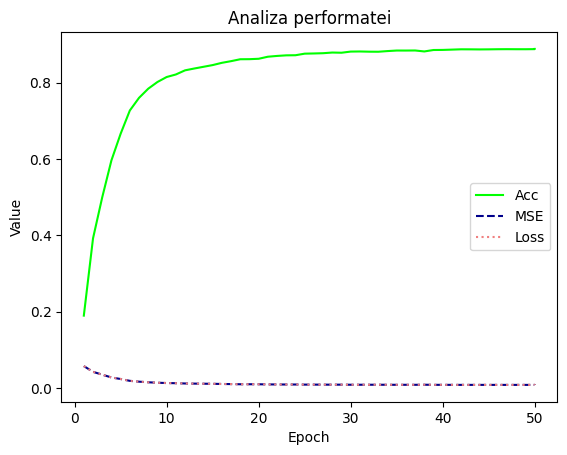

In [14]:
plt.plot(data["epoch"], data["acc"], c='lime', label='Acc')
plt.plot(data["epoch"], data["mse"], c='darkblue', ls='--', label='MSE')
plt.plot(data["epoch"], data["loss"], c='lightcoral', ls=':', label='Loss')
plt.title('Analiza performatei')
plt.xlabel('Epoch')
plt.ylabel('Value')
plt.legend()
plt.savefig(os.path.join(os.path.dirname(csv_path), "performance.pdf"))
plt.show()
